In [1]:
import pandas as pd
df= pd.read_csv('https://bit.ly/fish_csv_data')
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
import numpy as np
fish_data = df[['Weight', 'Length','Diagonal',  'Height', 'Width']]
fish_target=df ["Species"].to_numpy()

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train_input , test_input , train_target, test_target = train_test_split(
    fish_data ,fish_target,  test_size=0.2 , random_state=42
)

In [7]:
  from sklearn.preprocessing import StandardScaler
  ss= StandardScaler()
  ss.fit(train_input)

  train_scaled = ss.transform(train_input)
  test_scaled = ss.transform(test_input)

In [8]:
from sklearn.linear_model import SGDClassifier

In [11]:
sc  = SGDClassifier(loss='log_loss',n_jobs=-1 ) # 로지스틱 손실 함수 - binary crossentropy , categorical crossentropy


In [13]:
sc.fit(train_scaled, train_target)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [21]:
print("훈련 세트: ", sc.score(train_scaled, train_target))
print("테스트세트:", sc.score(test_scaled, test_target))

훈련 세트:  0.937007874015748
테스트세트: 0.90625


In [18]:
sc.partial_fit(train_scaled, train_target)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [20]:
print("훈련 세트: ", sc.score(train_scaled, train_target))
print("테스트세트:", sc.score(test_scaled, test_target))

훈련 세트:  0.937007874015748
테스트세트: 0.90625


In [23]:
sc.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype='<U9')

In [26]:
import numpy as np
np.round(sc.predict_proba(test_scaled[:5]), decimals=3)

array([[0.   , 0.   , 0.564, 0.   , 0.436, 0.   , 0.   ],
       [0.   , 0.   , 0.037, 0.   , 0.083, 0.88 , 0.   ],
       [0.   , 0.   , 0.   , 0.967, 0.033, 0.   , 0.   ],
       [0.   , 0.   , 0.428, 0.   , 0.572, 0.   , 0.   ],
       [0.   , 0.   , 0.554, 0.   , 0.446, 0.   , 0.   ]])

In [34]:
sc = SGDClassifier(max_iter=1, tol=None, loss='log_loss')
sc.fit(train_scaled, train_target)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1
,tol,None
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [35]:
train_score =[]
test_score =[]
for _ in range(500):
    sc.partial_fit(train_scaled, train_target)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))


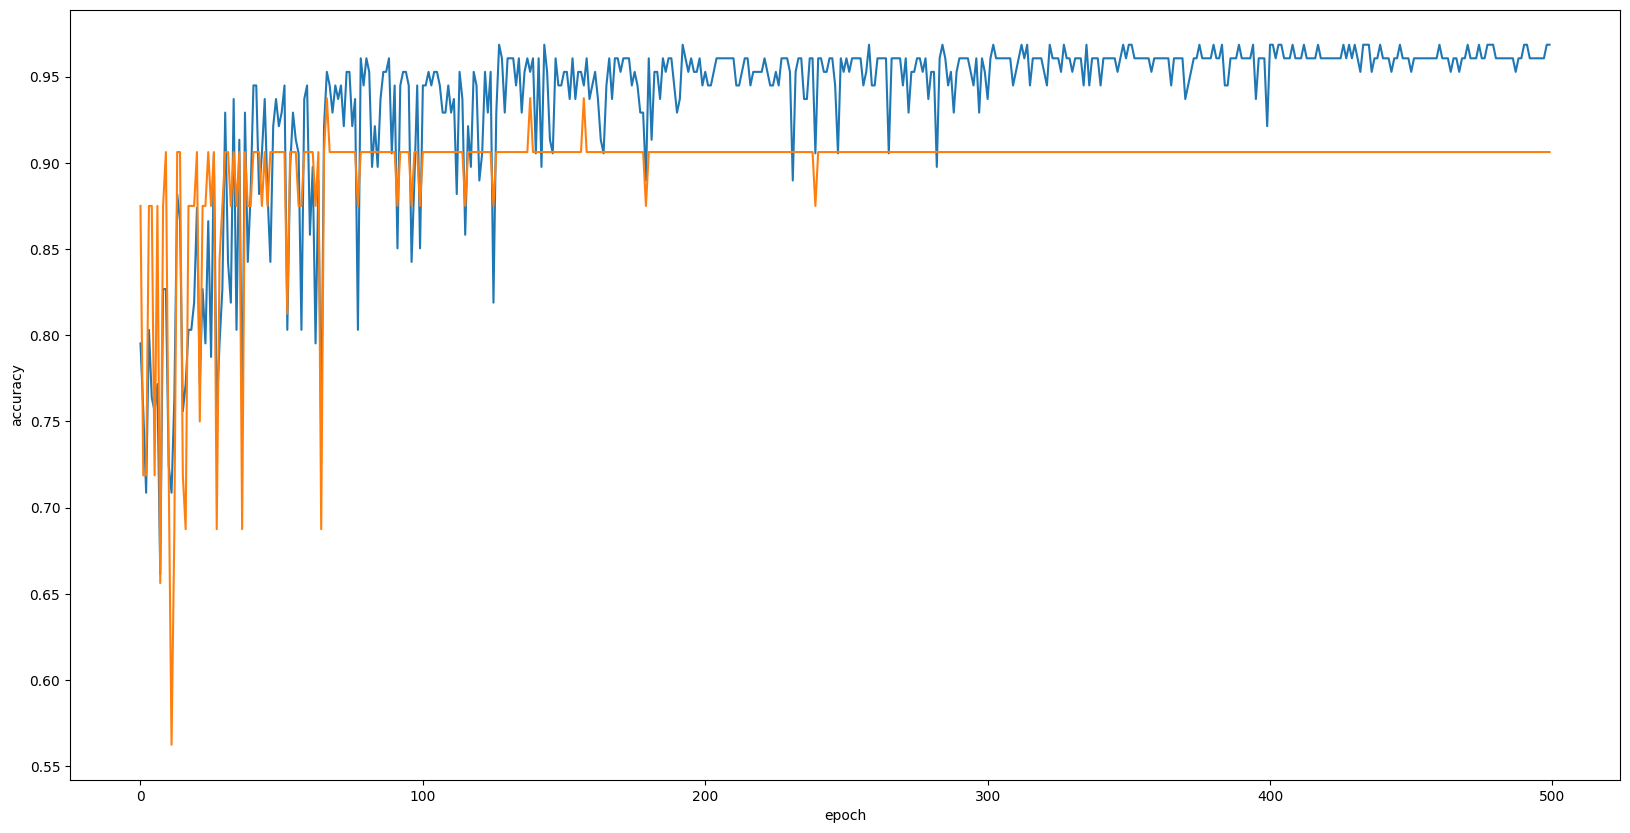

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel("accuracy")
plt.show()

In [38]:
sc = SGDClassifier(max_iter=1, tol=None, loss='log_loss')
sc.fit(train_scaled, train_target)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1
,tol,None
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [39]:
print("훈련 세트: ", sc.score(train_scaled, train_target))
print("테스트세트:", sc.score(test_scaled, test_target))

훈련 세트:  0.7559055118110236
테스트세트: 0.8125


In [51]:
# GridSearchCV를 통한 최적의 하이퍼파라미터와 최적의 모델을 검색 
from sklearn.model_selection import GridSearchCV
params = {
    'max_iter': np.arange(50, 1000),
    'tol': np.arange(0.0001, 1, 0.0001),
    'alpha': [0.0001, 0.001, 0.1, 1, 10, 100, 100]
}

sc = SGDClassifier(loss='log_loss')
gs = GridSearchCV(sc, params, n_jobs=-1)

In [52]:
gs.fit(train_scaled, train_target)

KeyboardInterrupt: 

In [53]:

# RandomizedSearchCV 
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

params = {
    'max_iter': randint(50, 1000),
    'tol': uniform(0.001, 1),
    'alpha': uniform(0.001, 100)
}

In [55]:
rs.fit(train_scaled, train_target)

NameError: name 'rs' is not defined

In [ ]:

rs.best_params_

In [ ]:
model = rs.best_estimator_
model

In [ ]:
print("학습세트:", model.score(train_scaled, train_target))
print("테스트세트:", model.score(test_scaled, test_target))

NameError: name 'RandomizedSearchCv' is not defined